# Etape 1 - Importation des librairies et chargement des fichiers

### 1.1 - Importation des librairies

In [ ]:
#Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

#Importation de la librairie plotly express
import plotly.express as px

In [ ]:
#permet d'aller prendre les fichiers directement dans mon drive
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My Drive/Colab Notebooks/Lapage/

Mounted at /content/drive/
/content/drive/My Drive/Colab Notebooks/Lapage


In [ ]:
#afficher toutes les colonnes de mon dataframe
pd.set_option('display.max_columns', None)

### 1.2 - Chargements des fichiers

In [ ]:
#Importation du fichier customers.csv
df_customers = pd.read_csv("customers.csv", sep=";")
#Importation du fichier products.csv
df_products = pd.read_csv("products.csv", sep=";")
#Importation du fichier Transactions.csv
df_transactions = pd.read_csv("Transactions.csv", sep=";")

/tmp/ipython-input-3021559041.py:6: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions = pd.read_csv("Transactions.csv", sep=";")


# Etape 2 - Analyse exploratoire des fichiers

### 2.1 - Analyse exploratoire du fichier customers.csv

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_customers.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_customers.shape[1]))

Le tableau comporte 8621 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est de : ",df_customers.shape[1],"\n")
#La nature des données dans chacune des colonnes
print("Nature des données pour chaques colonnes :\n", df_customers.dtypes,"\n")
#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs par colonnes :\n", df_customers.count())

Le nombre de colonnes est de :  3 

Nature des données pour chaques colonnes :
 client_id    object
sex          object
birth         int64
dtype: object 

Nombre de valeurs par colonnes :
 client_id    8621
sex          8621
birth        8621
dtype: int64


In [ ]:
#Afficher les 5 premières lignes de la table
df_customers.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


### 2.2 - Analyse exploratoire du fichier products.csv

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_products.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_products.shape[1]))

Le tableau comporte 3286 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est de : ",df_products.shape[1],"\n")
#La nature des données dans chacune des colonnes
print("Nature des données pour chaques colonnes :\n", df_products.dtypes,"\n")
#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs par colonnes :\n", df_products.count())

Le nombre de colonnes est de :  3 

Nature des données pour chaques colonnes :
 id_prod     object
price      float64
categ        int64
dtype: object 

Nombre de valeurs par colonnes :
 id_prod    3286
price      3286
categ      3286
dtype: int64


In [ ]:
#Afficher les 5 premières lignes de la table
df_products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


### 2.3 - Analyse exploratoire du fichier Transactions.csv

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_transactions.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_transactions.shape[1]))

Le tableau comporte 1048575 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [ ]:
#Afficher les lignes vides
df_transactions.isna().sum()

#Supprimer les lignes vides
df_transactions = df_transactions.dropna()

In [ ]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est de : ",df_transactions.shape[1],"\n")
#Consulter le nombre de ligns
print("Le nombre de lignes est de : ",df_transactions.shape[0],"\n")
#La nature des données dans chacune des colonnes
print("Nature des données pour chaques colonnes :\n", df_transactions.dtypes,"\n")
#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs par colonnes :\n", df_transactions.count())

Le nombre de colonnes est de :  4 

Le nombre de lignes est de :  687534 

Nature des données pour chaques colonnes :
 id_prod       object
date          object
session_id    object
client_id     object
dtype: object 

Nombre de valeurs par colonnes :
 id_prod       687534
date          687534
session_id    687534
client_id     687534
dtype: int64


In [ ]:
#Afficher les 5 premières lignes de la table
df_transactions.head()

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


# Etape 3 - Jonction des fichiers

### Etape 3.1 - Jonction du fichier df_transactions et df_customers

In [ ]:
#Fusion des fichiers df_transactions et df_customers
df_merge = pd.merge(df_transactions, df_customers, on='client_id', how='left')
display(df_merge)


,id_prod,date,session_id,client_id,sex,birth
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,f,1967
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,m,1960
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,m,1988
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,f,1989
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,f,1956
...,...,...,...,...,...,...
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,f,1996
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,f,1994
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,f,1985
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,m,1953


### Etape 3.2 - Jonction du fichier df_merge et df_products

In [ ]:
#Fusion des fichiers df_merge et df_products
df_merge_global = pd.merge(df_merge, df_products, on='id_prod', how='inner')
display(df_merge_global)

,id_prod,date,session_id,client_id,sex,birth,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,f,1967,11.99,0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,m,1960,19.37,0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,m,1988,4.50,0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,f,1989,6.55,0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,f,1956,16.49,0
...,...,...,...,...,...,...,...,...
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,f,1996,21.92,1
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,f,1994,48.99,2
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,f,1985,26.99,1
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,m,1953,8.99,0


# Etape 4 - Analyse du chiffre d’affaires

### Etape 4.1 - Chiffre d’affaires avec la moyenne mobile

In [ ]:
#Tranformer les dates pour n'avoir plus que le jour sans les heures minutes
df_merge_global['date'] = pd.to_datetime(df_merge_global['date']).dt.normalize()
df_merge_global['date']


#Calculer le chiffre d'affaire par jour
df_CA_journalier = df_merge_global.groupby(['date'], as_index=False).agg({'price': 'sum'})

display(df_CA_journalier)
print(df_merge_global.dtypes)


,date,price
0,2021-03-01,16565.22
1,2021-03-02,15486.45
2,2021-03-03,15198.69
3,2021-03-04,15196.07
4,2021-03-05,17471.37
...,...,...
725,2023-02-24,15207.89
726,2023-02-25,15761.25
727,2023-02-26,16304.72
728,2023-02-27,19170.81


id_prod               object
date          datetime64[ns]
session_id            object
client_id             object
sex                   object
birth                  int64
price                float64
categ                  int64
dtype: object


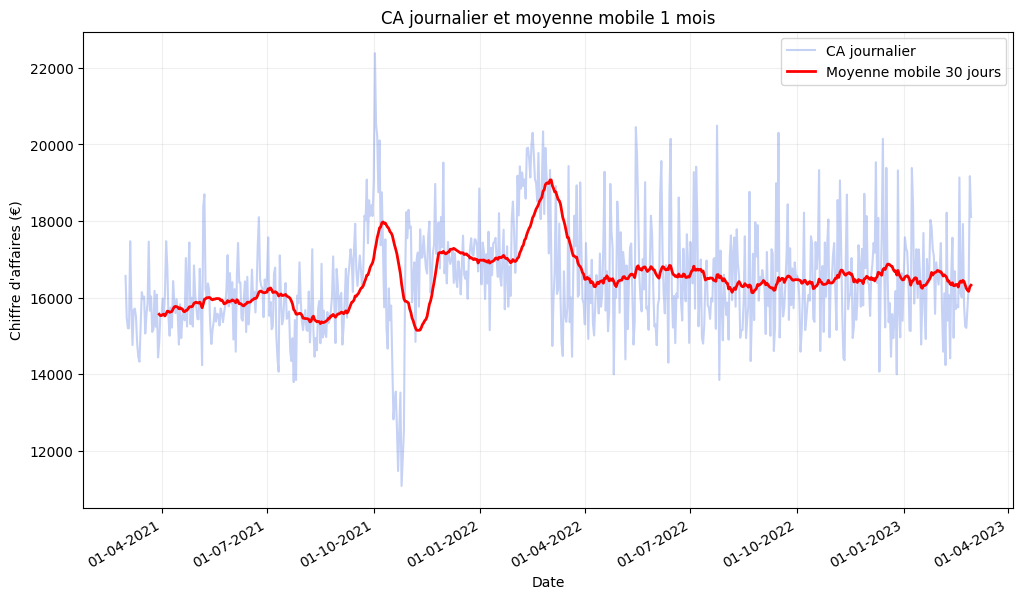

In [ ]:
#Faire un graphique du chiffre d’affaires avec la moyenne mobile

#trier par date
df_CA_journalier = df_CA_journalier.sort_values('date')

#créer le graphique
plt.figure(figsize=(12, 7))
plt.plot(df_CA_journalier['date'], df_CA_journalier['price'], linestyle='-', color='royalblue', label="CA journalier", alpha=0.3)
plt.plot(df_CA_journalier['date'], df_CA_journalier['price'].rolling(30).mean(), linestyle='-', color='red', label="Moyenne mobile 30 jours", linewidth=2)

# Formater l'axe des X pour afficher les dates correctement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotation automatique des dates pour lisibilité

plt.legend()

plt.title('CA journalier et moyenne mobile 1 mois')
plt.xlabel('Date')
plt.ylabel('Chiffre d\'affaires (€)')
plt.grid(alpha=0.2)
plt.show()

### Etape 4.2 - Chiffre d’affaires par catégorie


In [ ]:
display(df_merge_global)

,id_prod,date,session_id,client_id,sex,birth,price,categ
0,0_1259,2021-03-01,s_1,c_329,f,1967,11.99,0
1,0_1390,2021-03-01,s_2,c_664,m,1960,19.37,0
2,0_1352,2021-03-01,s_3,c_580,m,1988,4.50,0
3,0_1458,2021-03-01,s_4,c_7912,f,1989,6.55,0
4,0_1358,2021-03-01,s_5,c_2033,f,1956,16.49,0
...,...,...,...,...,...,...,...,...
687529,1_508,2023-02-28,s_348444,c_3573,f,1996,21.92,1
687530,2_37,2023-02-28,s_348445,c_50,f,1994,48.99,2
687531,1_695,2023-02-28,s_348446,c_488,f,1985,26.99,1
687532,0_1547,2023-02-28,s_348447,c_4848,m,1953,8.99,0


In [ ]:
#Calculer le chiffre d'affaire par catégorie
df_CA_total_cat  = df_merge_global.groupby('categ')['price'].sum()

print("le Ca pour la catégorie 0 est de : ", round(df_CA_total_cat[0],2), "€\n")
print("le Ca pour la catégorie 1 est de : ", round(df_CA_total_cat[1],2), "€\n")
print("le Ca pour la catégorie 2 est de : ", round(df_CA_total_cat[2],2), "€")

display(df_CA_total_cat)

le Ca pour la catégorie 0 est de :  4419730.97 €

le Ca pour la catégorie 1 est de :  4827657.11 €

le Ca pour la catégorie 2 est de :  2780275.02 €


,price
categ,
0,4419730.97
1,4827657.11
2,2780275.02


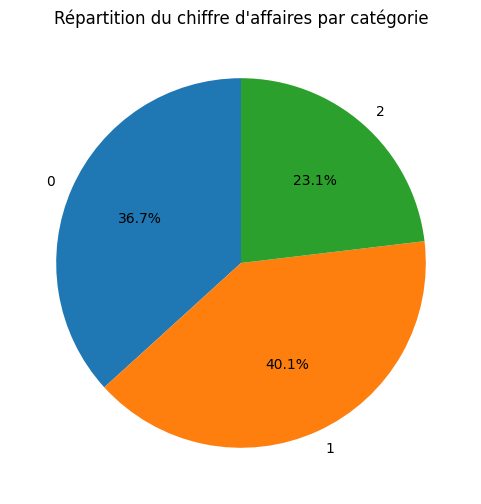

In [ ]:
#Faire un graphique du chiffre d’affaires par catégorie
plt.figure(figsize=(6,6))
df_CA_total_cat.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Répartition du chiffre d'affaires par catégorie")
plt.ylabel("")  # enlève le label sur l'axe vertical
plt.show()


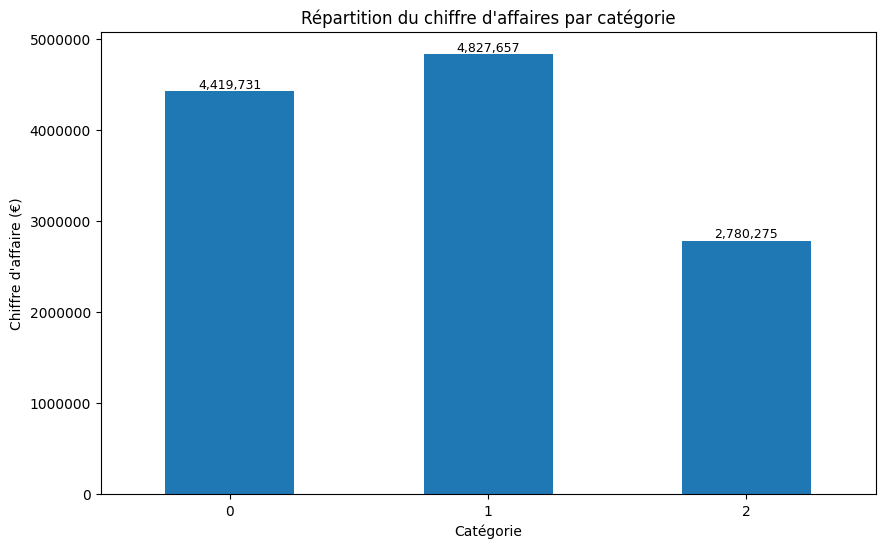

In [ ]:
#Faire un graphique du chiffre d’affaires par catégorie
plt.figure(figsize=(10,6))
bar = df_CA_total_cat.plot(kind='bar', )
plt.title("Répartition du chiffre d'affaires par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Chiffre d'affaire (€)")

# Ajouter les valeurs sur chaque barre
for p in bar.patches:
    value = p.get_height()
    bar.annotate(f'{value:,.0f}',  # format avec séparateur milliers
                (p.get_x() + p.get_width() / 2, value),
                ha='center', va='bottom', # positionnement du texte
                fontsize=9)

bar.ticklabel_format(style='plain', axis='y') # affiche la valeur complète sur l'axe des y
plt.xticks(rotation=0) #affiche correctement les catégories sur l'axe x car elles étaient tournées à 90°

plt.show()

### Etape 4.3 - Chiffre d’affaires par catégorie dans le temps

In [ ]:
#Calculer le chiffre d'affaire par catégorie
df_CA_categorie  = df_merge_global.groupby(['date','categ'])['price'].sum()

#Création d'un dataframe mensuel et non journalier
df2 = df_CA_categorie.reset_index()
df2['mois'] = df2['date'].dt.to_period('M') #on transforme pour que les dates soit aggrégées en mois, meilleur visuel graphique
df_CA_mensuel = df2.groupby(['mois', 'categ'])['price'].sum().reset_index() #on fregroupe par mois et catégories en réalisant la somme des prix pour avoir le CA

display(df_CA_mensuel)


,mois,categ,price
0,2021-03,0,193629.17
1,2021-03,1,186974.17
2,2021-03,2,101837.27
3,2021-04,0,205222.46
4,2021-04,1,156138.35
...,...,...,...
67,2023-01,1,210104.41
68,2023-01,2,126153.08
69,2023-02,0,162457.00
70,2023-02,1,180347.24


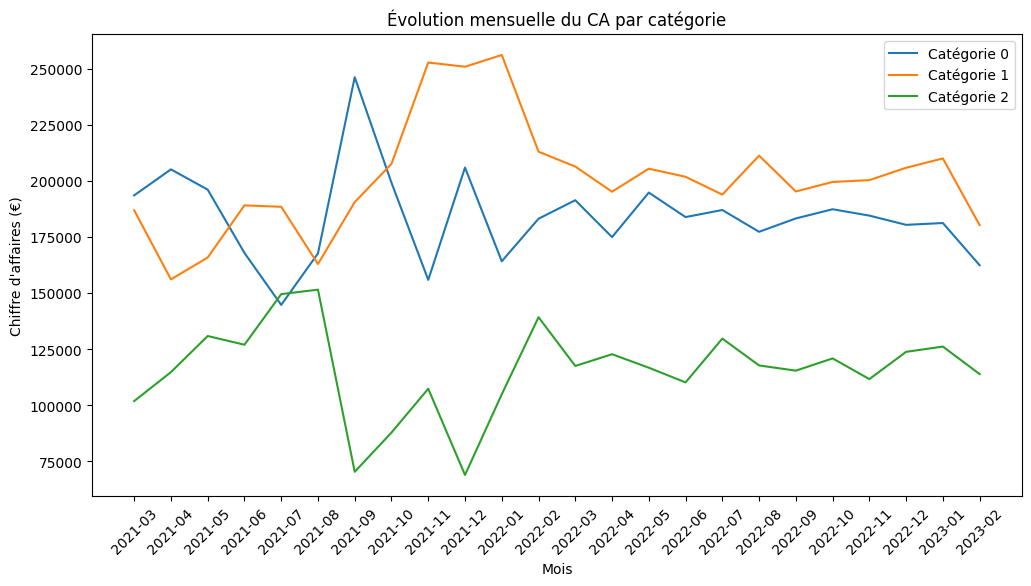

In [ ]:
#Création du graphique
# Partir de df_CA_categorie (CA par jour + par catégorie)
df2 = df_CA_categorie.reset_index()

# Convertir mois en string pour l'affichage en X
df_CA_mensuel['mois'] = df_CA_mensuel['mois'].astype(str)

# Tracer l'évolution mensuelle
plt.figure(figsize=(12,6))

for cat in df_CA_mensuel['categ'].unique():
    df_temp = df_CA_mensuel[df_CA_mensuel['categ'] == cat]
    plt.plot(df_temp['mois'], df_temp['price'], label=f'Catégorie {cat}')

plt.xlabel('Mois')
plt.ylabel('Chiffre d\'affaires (€)')
plt.title('Évolution mensuelle du CA par catégorie')
plt.legend()
plt.xticks(rotation=45)
plt.show()

### Etape 4.4 - Nombre de clients par mois

In [ ]:
#Création d'une colonne mois dans notre dataframe de départ
df_merge_global['mois'] = df_merge_global['date'].dt.to_period('M')

#Création d'un dataframe du nombre de clients par mois
df_clients = df_merge_global.groupby('mois')['client_id'].nunique().reset_index()
df_clients = df_clients.rename(columns={'client_id': 'nb_clients'})

display(df_clients.head())

,mois,nb_clients
0,2021-03,5676
1,2021-04,5674
2,2021-05,5644
3,2021-06,5659
4,2021-07,5672


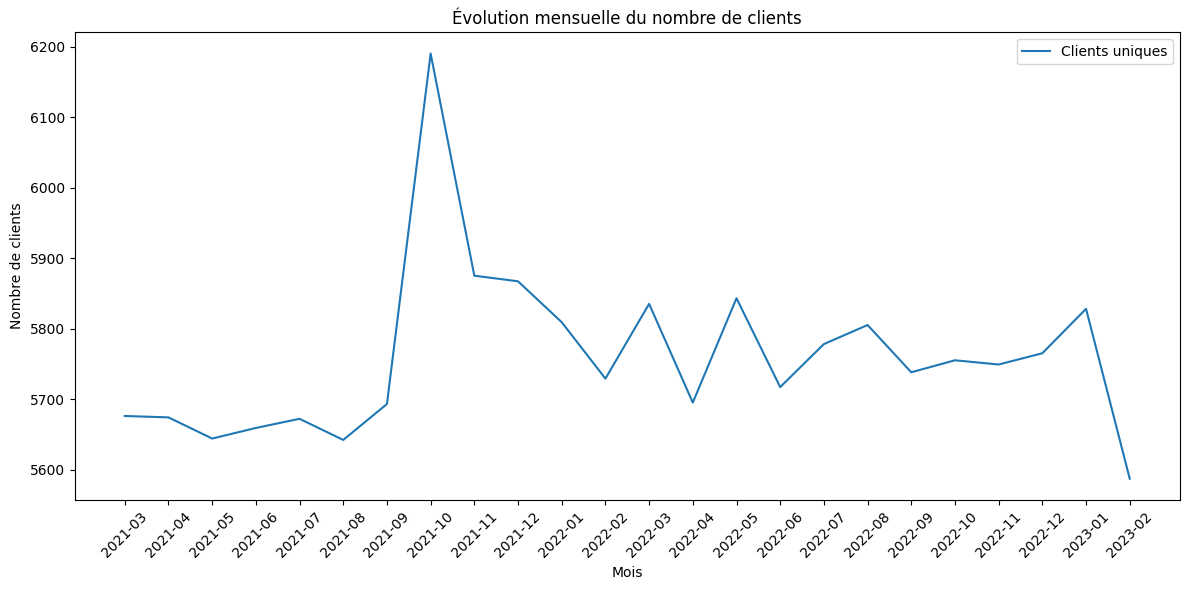

In [ ]:
#Création d'un graphique du nombre de client par mois
plt.figure(figsize=(12,6))

df_clients['mois'] = df_clients['mois'].astype(str)

plt.plot(df_clients['mois'], df_clients['nb_clients'], label='Clients uniques')

plt.xlabel('Mois')
plt.ylabel('Nombre de clients')
plt.title('Évolution mensuelle du nombre de clients')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Etape 4.5 - Nombre de transactions par mois

In [ ]:
#Création d'un dataframe du nombre de transactions par mois
df_transactions_mois = df_merge_global.groupby('mois')['session_id'].nunique().reset_index()
display(df_transactions_mois.head())


,mois,session_id
0,2021-03,14201
1,2021-04,13970
2,2021-05,14168
3,2021-06,13838
4,2021-07,13571


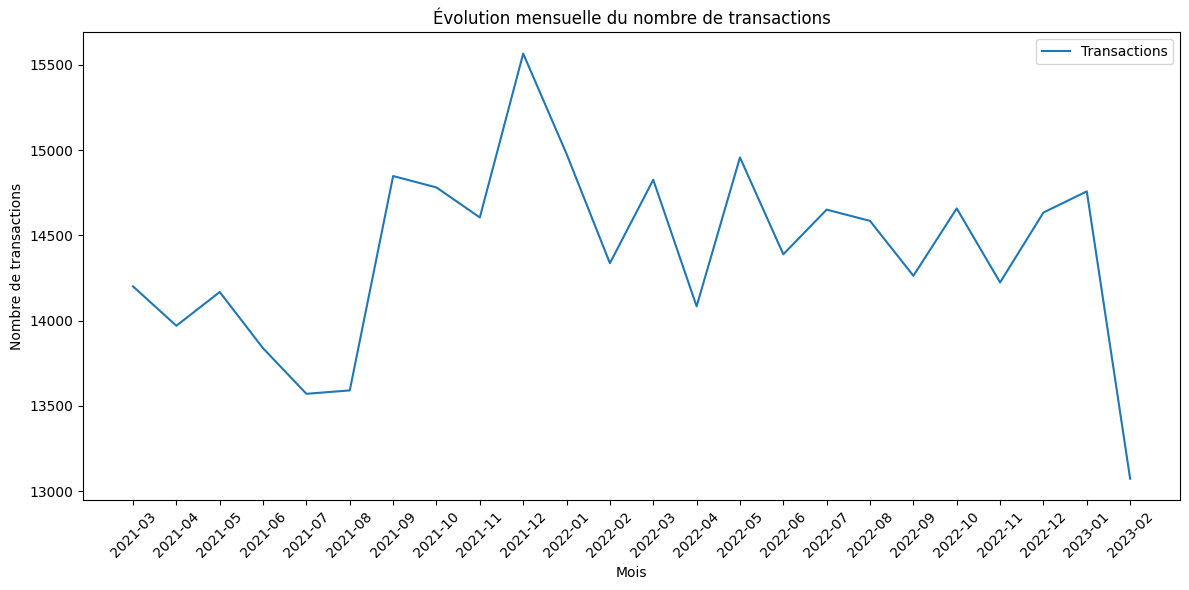

In [ ]:
#Création d'un graphique du nombre de client par mois
plt.figure(figsize=(12,6))

df_transactions_mois['mois'] = df_transactions_mois['mois'].astype(str)

plt.plot(df_transactions_mois['mois'], df_transactions_mois['session_id'], label='Transactions')

plt.xlabel('Mois')
plt.ylabel('Nombre de transactions')
plt.title('Évolution mensuelle du nombre de transactions')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Etape 4.6 - Nombre de produits vendus

In [ ]:
#Création d'un dataframe du nombre de produits vendus mensuellement
df_produits_mensuel = df_merge_global.groupby('mois').size().reset_index(name='nb_produits')

display(df_produits_mensuel.head())

,mois,nb_produits
0,2021-03,28601
1,2021-04,28443
2,2021-05,28285
3,2021-06,26850
4,2021-07,24738


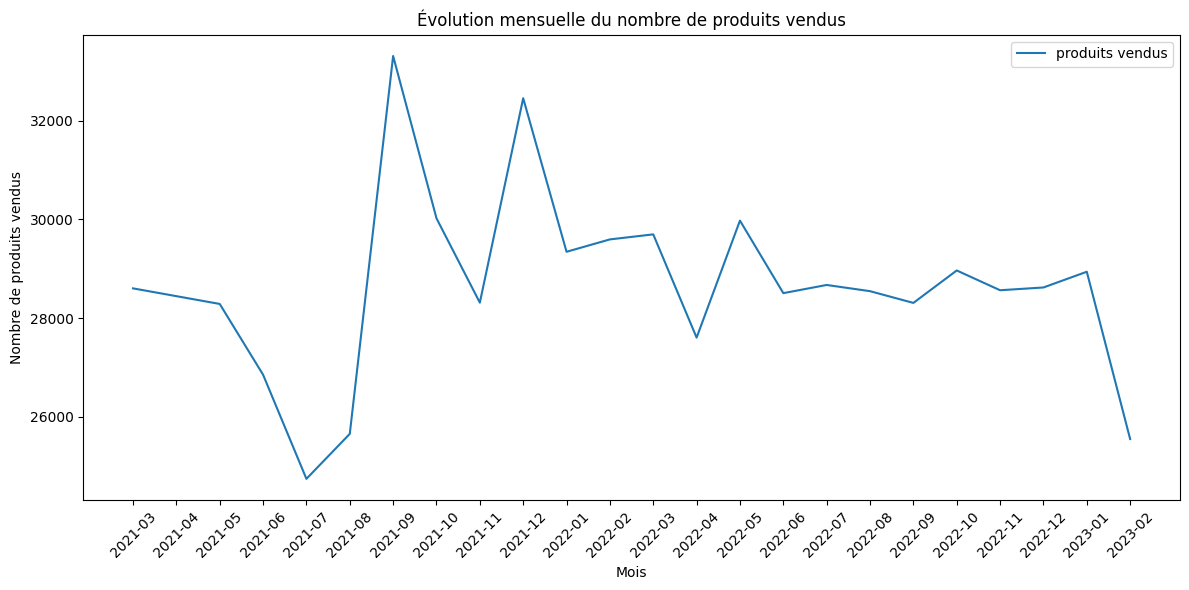

In [ ]:
#Création d'un graphique du nombre de produits vendus mensuellement
plt.figure(figsize=(12,6))

df_produits_mensuel['mois'] = df_produits_mensuel['mois'].astype(str)

plt.plot(df_produits_mensuel['mois'], df_produits_mensuel['nb_produits'], label='produits vendus')

plt.xlabel('Mois')
plt.ylabel('Nombre de produits vendus')
plt.title('Évolution mensuelle du nombre de produits vendus')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Etape 5 - Analyse des références

### Etape 5.1 - Top 20 des ventes

In [ ]:
display(df_merge_global.head())

,id_prod,date,session_id,client_id,sex,birth,price,categ,mois
0,0_1259,2021-03-01,s_1,c_329,f,1967,11.99,0,2021-03
1,0_1390,2021-03-01,s_2,c_664,m,1960,19.37,0,2021-03
2,0_1352,2021-03-01,s_3,c_580,m,1988,4.50,0,2021-03
3,0_1458,2021-03-01,s_4,c_7912,f,1989,6.55,0,2021-03
4,0_1358,2021-03-01,s_5,c_2033,f,1956,16.49,0,2021-03


In [ ]:
#Création d'un dataframe regroupant les produits
df_produits = df_merge_global.groupby('id_prod').size().reset_index(name='nb_ventes_produit')
df_produits = df_produits.sort_values('nb_ventes_produit', ascending=False)

display(df_produits.head())

,id_prod,nb_ventes_produit
2591,1_369,2340
2644,1_417,2269
2641,1_414,2246
2733,1_498,2202
2653,1_425,2163


In [ ]:
#Création d'un graphique du Top 20 des produits les plus vendus
df_produits_20 =  df_produits.head(20)

fig = px.bar(
    df_produits_20,
    x='id_prod',
    y='nb_ventes_produit',
    title="Top 20 des meilleures ventes",
    labels={'id_prod': 'ID produit','nb_ventes_produit': 'Nombre de ventes'},
    text='nb_ventes_produit'
)

fig.update_layout(
    height=900,
    width=1500,
    xaxis_title="Référence produit",
    yaxis_title="Nombre de ventes"
)

fig.show()


### Etape 5.2 - Top 20 des flops ventes

In [ ]:
#Création d'un graphique du Top 10 des produits les moins vendus
df_produits = df_produits.sort_values('nb_ventes_produit')
df_produits_20_pires =  df_produits.head(20)

fig = px.bar(
    df_produits_20_pires,
    y='id_prod',
    x='nb_ventes_produit',
    labels={'id_prod': 'ID produit','nb_ventes_produit': 'Nombre de ventes'},
    orientation='h',
    title='Top 20 des flops des ventes',
    text='nb_ventes_produit'
)

fig.update_layout(
    height=900,
    width=1500,
    xaxis_title="Nombre de ventes",
    yaxis_title="Référence produit"
)
fig.update_xaxes(dtick=1)

fig.show()

### Etape 5.3 - Répartition par catégories par nombre de ventes

In [ ]:
#Création d'un dataframe regroupant le nombre de ventes par catégorie
df_cat_volume = df_merge_global.groupby('categ').size().reset_index(name='nb_ventes_categ')
display(df_cat_volume)

,categ,nb_ventes_categ
0,0,415459
1,1,235592
2,2,36483


In [ ]:
#Création d'un graphique de la répartition du nombre de ventes par catégorie
labels = {0: "Catégorie 0", 1: "Catégorie 1", 2: "Catégorie 2"}
df_cat_volume['categ'] = df_cat_volume['categ'].map(labels)

fig = px.pie(
    df_cat_volume,
    names='categ',
    values='nb_ventes_categ',
    labels={'categ': 'Groupe','nb_ventes_categ': 'Nombre de ventes'},
    title="Répartition des produits vendus par catégorie"
)
fig.update_layout(width=700, height=500)
fig.show()

### Etape 5.4 - Prix moyen par catégorie

In [ ]:
# Création d'un dataframe des produits
df_produit = df_merge_global.groupby(['id_prod', 'categ'])['price'].mean().reset_index()
display(df_produit)

,id_prod,categ,price
0,0_0,0,3.75
1,0_1,0,10.99
2,0_10,0,17.95
3,0_100,0,20.60
4,0_1000,0,6.84
...,...,...,...
3260,2_95,2,98.99
3261,2_96,2,47.91
3262,2_97,2,160.99
3263,2_98,2,149.74


In [ ]:
#création Dataframe avec prix moyen par catégorie

df_cat_prix = df_produit.groupby('categ')['price'].mean().reset_index()
df_cat_prix['price'] = round(df_cat_prix['price'], 2)

display(df_cat_prix)


,categ,price
0,0,11.71
1,1,25.50
2,2,107.64


In [ ]:
#création du graph
fig = px.bar(
    df_cat_prix,
    x='categ',
    y='price',
    title="Prix moyen pour chaque catégorie",
    labels={'categ': 'Catégorie','price': 'Prix moyen'},
    text='price'
)

fig.update_layout(
    height=600,
    width=900,
    xaxis_title="catégorie",
    yaxis_title="Prix moyen (€)",
    xaxis=dict(
        tickmode='array',
        tickvals=[0, 1, 2]   # ← affiche uniquement ces valeurs
    )
)

fig.show()

#création d'un boxplot
fig = px.box(
    df_produit,
    x="categ",
    y="price",
    color="categ",
    points="outliers",
    hover_data=['id_prod'], # Ajout de l'ID au survol comme suggéré
    title="Distribution des prix par catégorie",
    labels={"price": "Prix Moyen (€)", "categ": "Catégorie"},
    width=600,  # On force une largeur raisonnable
    height=500  # On garde une bonne hauteur pour voir la distribution
)

# On resserre les boîtes pour qu'elles ne soient pas trop fines
fig.update_layout(
    bargap=0.3, # Espace entre les groupes
    boxgap=0.4, # Espace à l'intérieur des groupes
    showlegend=False
)

fig.show()

# Etape 6 - Analyse des profils de nos client

### Etape 6.1 - Chiffre d'affaires BtoB

In [ ]:
#Création liste clients BtoB, clients avec plus de 1000 achats
clients_btob = (df_merge_global.groupby('client_id').size().reset_index(name='nb_achats').query('nb_achats > 1000'))
display(clients_btob)

#On regroupe les depenses des clients BtoB par catégories
df_btob_ca = (df_merge_global.merge(clients_btob[['client_id']], on='client_id').groupby('categ', as_index=False).agg(ca_btob=('price', 'sum'))) # on fait un filtrage par jointure puis on groupe par catégorie faisant une aggréggation sur le prix

#Calcul de la part du CA
df_btob_ca['part_ca_btob_%'] = round((df_btob_ca['ca_btob'] / (df_btob_ca['ca_btob'].sum())) * 100,2)

display(df_btob_ca)

,client_id,nb_achats
677,c_1609,25586
2724,c_3454,6793
4388,c_4958,5222
6337,c_6714,9199


,categ,ca_btob,part_ca_btob_%
0,0,300530.28,33.99
1,1,307555.25,34.78
2,2,276210.56,31.24


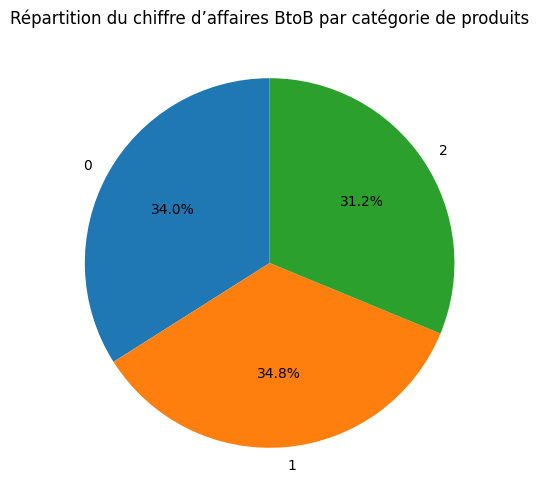

In [ ]:
#Faire un graphique du chiffre d’affaires par clients BtoB
plt.figure(figsize=(6,6))
plt.pie(
    df_btob_ca['ca_btob'],
    labels=df_btob_ca['categ'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Répartition du chiffre d’affaires BtoB par catégorie de produits")
plt.show()

,id_prod,date,session_id,client_id,sex,birth,price,categ,mois
0,0_1304,2021-03-01,s_7,c_1609,m,1980,5.86,0,2021-03
1,0_1159,2021-03-01,s_7,c_1609,m,1980,7.99,0,2021-03
2,0_1431,2021-03-01,s_33,c_3454,m,1969,10.99,0,2021-03
3,0_1425,2021-03-01,s_46,c_1609,m,1980,12.99,0,2021-03
4,0_1469,2021-03-01,s_53,c_1609,m,1980,14.99,0,2021-03
...,...,...,...,...,...,...,...,...,...
46795,0_1333,2023-02-28,s_348416,c_6714,f,1968,5.99,0,2023-02
46796,1_392,2023-02-28,s_348416,c_6714,f,1968,18.11,1,2023-02
46797,2_13,2023-02-28,s_348403,c_4958,m,1999,50.99,2,2023-02
46798,1_183,2023-02-28,s_348416,c_6714,f,1968,24.99,1,2023-02


,client_id,categ,depenses_btob
0,c_1609,0,214447.24
1,c_1609,1,110091.44
2,c_1609,2,1501.21
3,c_3454,0,28779.69
4,c_3454,1,84055.66
5,c_3454,2,1275.22
6,c_4958,0,48.76
7,c_4958,1,39841.93
8,c_4958,2,250336.34
9,c_6714,0,57254.59


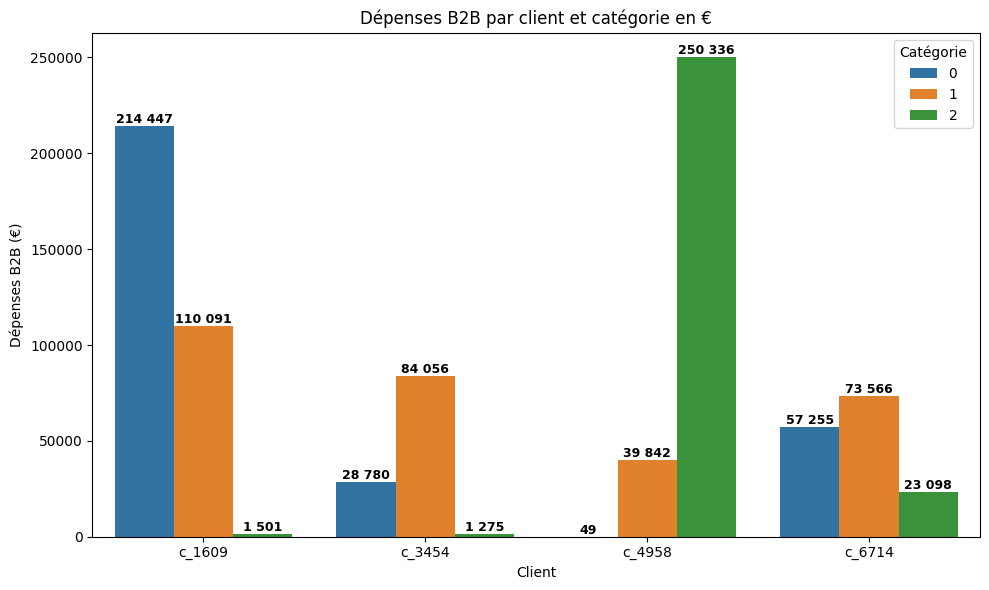

In [ ]:
#Dépenses des clients BtoB
df_btob_part = df_merge_global.merge(clients_btob[['client_id']], on='client_id')
display(df_btob_part)

df_btob_categ = df_btob_part.groupby(['client_id','categ'], as_index=False).agg(depenses_btob=('price', 'sum'))
display(df_btob_categ)


#Création du graph
palette = ['#1f77b4', '#ff7f0e', '#2ca02c']
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df_btob_categ,
    x='client_id',
    y='depenses_btob',
    hue='categ',
    palette=palette
)

#création des valeurs au dessus des axes
for container in ax.containers:
    labels = [f'{v:,.0f}'.replace(',', ' ') for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9, fontweight='bold')

plt.title("Dépenses B2B par client et catégorie en €")
plt.xlabel("Client")
plt.ylabel("Dépenses B2B (€)")
plt.legend(title="Catégorie")

plt.tight_layout()
plt.show()

### Etape 6.2 - Courbe de Lorenz

In [ ]:
#Création dataframe CA total par client
df_CA_client = df_merge_global.groupby('client_id')['price'].sum().reset_index(name='CA_client')


#Tris par ordre croissant
df_CA_client = df_CA_client.sort_values('CA_client').reset_index(drop=True)
display(df_CA_client.head())

,client_id,CA_client
0,c_8351,6.31
1,c_8140,8.30
2,c_8114,9.98
3,c_4648,11.20
4,c_4478,13.36


In [ ]:
#Calcul des sommes cumulées
df_CA_client['part_clients'] = (df_CA_client.index + 1) / len(df_CA_client) # Permet de faire la part cumulé des clients, ce client est dans les X% premiers

df_CA_client['part_CA'] = (df_CA_client['CA_client'].cumsum()) / df_CA_client['CA_client'].sum()
display(df_CA_client.head())
display(df_CA_client.tail())

,client_id,CA_client,part_clients,part_CA
0,c_8351,6.31,0.000116,5.246239e-07
1,c_8140,8.30,0.000233,1.214700e-06
2,c_8114,9.98,0.000349,2.044454e-06
3,c_4648,11.20,0.000465,2.975640e-06
4,c_4478,13.36,0.000581,4.086413e-06


,client_id,CA_client,part_clients,part_CA
8595,c_1570,5285.82,0.999535,0.926478
8596,c_3454,114110.57,0.999651,0.935965
8597,c_6714,153918.60,0.999767,0.948763
8598,c_4958,290227.03,0.999884,0.972892
8599,c_1609,326039.89,1.000000,1.000000


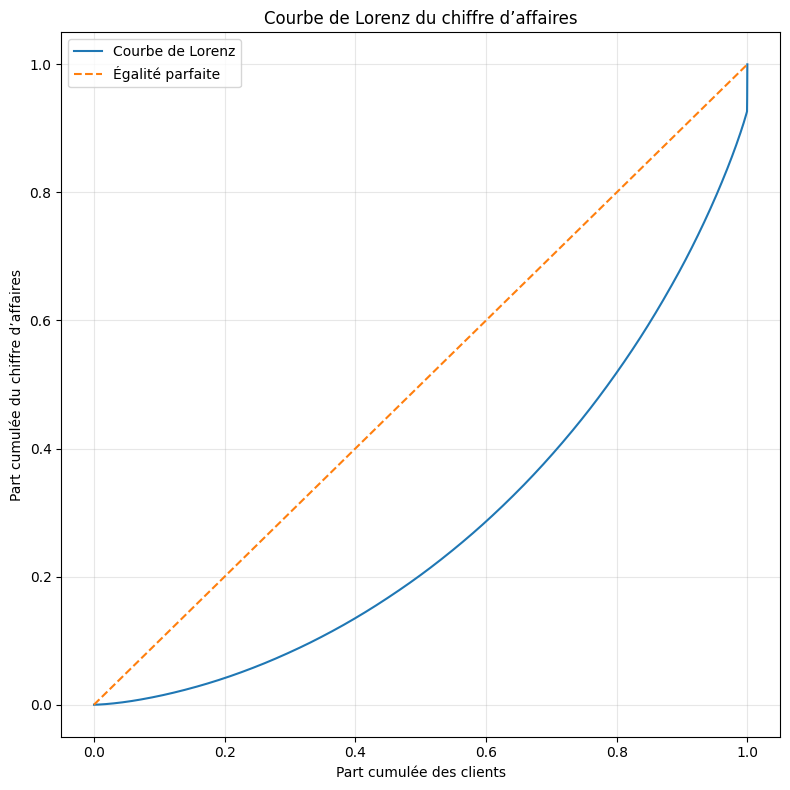

In [ ]:
#Création de la courbe de Lorenz
plt.figure(figsize=(8, 8))

# Courbe de Lorenz
plt.plot(df_CA_client['part_clients'], df_CA_client['part_CA'], label='Courbe de Lorenz')

# Droite d’égalité parfaite
plt.plot([0,1], [0,1], linestyle='--', label='Égalité parfaite')

plt.xlabel('Part cumulée des clients')
plt.ylabel('Part cumulée du chiffre d’affaires')
plt.title('Courbe de Lorenz du chiffre d’affaires')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Etape 7 - Préparation analyse complémentaires

### Etape 7.1 - Suppression clients BtoB et création fichier nettoyé

In [ ]:
#Création liste clients BtoB, clients avec plus de 1000 achats
clients_btob = (
    df_merge_global
    .groupby('client_id')
    .size()
    .reset_index(name='nb_achats')
    .query('nb_achats > 1000')
)
liste_btob = clients_btob['client_id'].tolist()
print(liste_btob)

#enlever les clients BtoB du dataframe
df_clean = df_merge_global[~df_merge_global['client_id'].isin(liste_btob)]
display(df_clean)

['c_1609', 'c_3454', 'c_4958', 'c_6714']


,id_prod,date,session_id,client_id,sex,birth,price,categ,mois
0,0_1259,2021-03-01,s_1,c_329,f,1967,11.99,0,2021-03
1,0_1390,2021-03-01,s_2,c_664,m,1960,19.37,0,2021-03
2,0_1352,2021-03-01,s_3,c_580,m,1988,4.50,0,2021-03
3,0_1458,2021-03-01,s_4,c_7912,f,1989,6.55,0,2021-03
4,0_1358,2021-03-01,s_5,c_2033,f,1956,16.49,0,2021-03
...,...,...,...,...,...,...,...,...,...
687529,1_508,2023-02-28,s_348444,c_3573,f,1996,21.92,1,2023-02
687530,2_37,2023-02-28,s_348445,c_50,f,1994,48.99,2,2023-02
687531,1_695,2023-02-28,s_348446,c_488,f,1985,26.99,1,2023-02
687532,0_1547,2023-02-28,s_348447,c_4848,m,1953,8.99,0,2023-02


### Etape 7.2 - Création fichier nettoyé

In [ ]:
#Création excel propre
df_clean.to_csv('df_clean.csv', index=False)